In [1]:
# Step 1: Install required libraries
#!pip install datasets

# Step 2: Import libraries
import re
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from collections import Counter
import random
import numpy as np


In [2]:
from google.colab import drive
drive.mount('gdrive')

Mounted at gdrive


In [3]:
!unzip /content/gdrive/MyDrive/ijcnlp_dailydialog.zip

Archive:  /content/gdrive/MyDrive/ijcnlp_dailydialog.zip
   creating: ijcnlp_dailydialog/
  inflating: ijcnlp_dailydialog/.DS_Store  
  inflating: ijcnlp_dailydialog/dialogues_act.txt  
  inflating: ijcnlp_dailydialog/dialogues_emotion.txt  
  inflating: ijcnlp_dailydialog/dialogues_text.txt  
  inflating: ijcnlp_dailydialog/dialogues_topic.txt  
  inflating: ijcnlp_dailydialog/readme.txt  
  inflating: ijcnlp_dailydialog/test.zip  
 extracting: ijcnlp_dailydialog/train.zip  
  inflating: ijcnlp_dailydialog/validation.zip  


In [4]:
import re

# Preprocessing - lowercasing and removing punctuation
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

questions = []
answers = []

# Read and process the entire dialogues_text.txt file
with open('/content/ijcnlp_dailydialog/dialogues_text.txt', 'r', encoding='utf-8') as f:
    for line in f:
        utterances = line.strip().split("__eou__")
        utterances = [preprocess(u.strip()) for u in utterances if u.strip()]
        for i in range(len(utterances) - 1):
            questions.append(utterances[i])
            answers.append(utterances[i + 1])

# Show a sample
print("Total Q&A pairs extracted:", len(questions))
print("Sample question:", questions[0])
print("Sample answer:", answers[0])


Total Q&A pairs extracted: 89862
Sample question: the kitchen stinks 
Sample answer: ill throw out the garbage 


In [5]:
# Special tokens
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

# Build vocabulary
all_sentences = questions + answers
word_counts = Counter(" ".join(all_sentences).split())
vocab = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN] + [word for word, count in word_counts.items() if count >= 2]

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(vocab)
pad_idx = word2idx[PAD_TOKEN]
bos_idx = word2idx[BOS_TOKEN]
eos_idx = word2idx[EOS_TOKEN]
unk_idx = word2idx[UNK_TOKEN]

In [6]:
def encode(sentence, max_len=20):
    tokens = sentence.split()
    tokens = [BOS_TOKEN] + tokens[:max_len - 2] + [EOS_TOKEN]
    ids = [word2idx.get(token, unk_idx) for token in tokens]
    padded = ids + [pad_idx] * (max_len - len(ids))
    return padded

max_len = 20
X = [encode(q, max_len) for q in questions]
Y = [encode(a, max_len) for a in answers]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
X_train, Y_train = torch.tensor(X_train), torch.tensor(Y_train)
X_test, Y_test = torch.tensor(X_test), torch.tensor(Y_test)

In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, tgt, hidden, cell):
        embedded = self.embedding(tgt)
        outputs, _ = self.lstm(embedded, (hidden, cell))
        logits = self.fc(outputs)
        return logits

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        hidden, cell = self.encoder(src)
        outputs = self.decoder(tgt, hidden, cell)
        return outputs

In [8]:
embed_size = 128
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(vocab_size, embed_size, hidden_size).to(device)
decoder = Decoder(vocab_size, embed_size, hidden_size).to(device)
model = Seq2Seq(encoder, decoder).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

EPOCHS = 40
BATCH_SIZE = 64

Epoch 1 Avg Loss: 5.4358
Epoch 2 Avg Loss: 4.7271
Epoch 3 Avg Loss: 4.4362
Epoch 4 Avg Loss: 4.2029
Epoch 5 Avg Loss: 4.0010
Epoch 6 Avg Loss: 3.8221
Epoch 7 Avg Loss: 3.6601
Epoch 8 Avg Loss: 3.5121
Epoch 9 Avg Loss: 3.3764
Epoch 10 Avg Loss: 3.2514
Epoch 11 Avg Loss: 3.1362
Epoch 12 Avg Loss: 3.0305
Epoch 13 Avg Loss: 2.9350
Epoch 14 Avg Loss: 2.8467
Epoch 15 Avg Loss: 2.7596
Epoch 16 Avg Loss: 2.6748
Epoch 17 Avg Loss: 2.5968
Epoch 18 Avg Loss: 2.5255
Epoch 19 Avg Loss: 2.4594
Epoch 20 Avg Loss: 2.3979
Epoch 21 Avg Loss: 2.3393
Epoch 22 Avg Loss: 2.2826
Epoch 23 Avg Loss: 2.2272
Epoch 24 Avg Loss: 2.1743
Epoch 25 Avg Loss: 2.1231
Epoch 26 Avg Loss: 2.0764
Epoch 27 Avg Loss: 2.0303
Epoch 28 Avg Loss: 1.9890
Epoch 29 Avg Loss: 1.9499
Epoch 30 Avg Loss: 1.9111
Epoch 31 Avg Loss: 1.8759
Epoch 32 Avg Loss: 1.8423
Epoch 33 Avg Loss: 1.8083
Epoch 34 Avg Loss: 1.7747
Epoch 35 Avg Loss: 1.7445
Epoch 36 Avg Loss: 1.7144
Epoch 37 Avg Loss: 1.6866
Epoch 38 Avg Loss: 1.6619
Epoch 39 Avg Loss: 1.

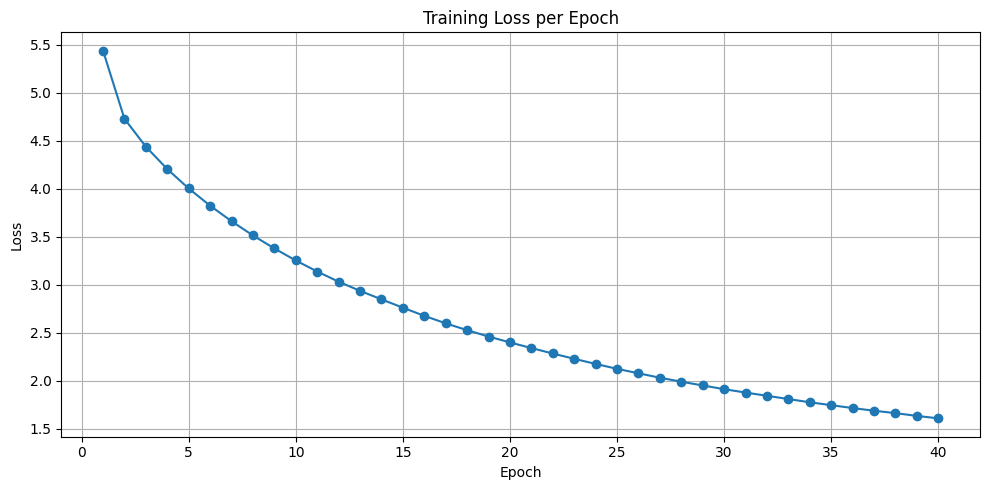

In [ ]:
import matplotlib.pyplot as plt

# Store losses
train_losses = []

# Updated training function with loss tracking
def train_model(model, X, Y, epochs=40, batch_size=64):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for i in range(0, len(X), batch_size):
            x_batch = X[i:i+batch_size].to(device)
            y_batch = Y[i:i+batch_size].to(device)

            tgt_input = y_batch[:, :-1]
            tgt_output = y_batch[:, 1:]

            logits = model(x_batch, tgt_input)
            loss = criterion(logits.view(-1, vocab_size), tgt_output.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / (len(X) // batch_size)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")

# Call training
train_model(model, X_train, Y_train, epochs=40, batch_size=64)

# Plot loss curve
def plot_loss_curve(losses):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(losses)+1), losses, marker='o', linestyle='-')
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call plotting function
plot_loss_curve(train_losses)

In [ ]:
# Define path to save in your MyDrive
save_path = "/content/gdrive/MyDrive/chatbot_dailydialog_seq2seq_no_attention.pth"

# Save model weights
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /content/gdrive/MyDrive/chatbot_dailydialog_seq2seq_no_attention.pth


In [9]:
import torch

# Recreate your model architecture
model = Seq2Seq(encoder, decoder).to(device)  # ✅ FIXED


# Define path where model was saved
load_path = "/content/gdrive/MyDrive/chatbot_dailydialog_seq2seq_no_attention.pth"

# Load the saved weights
model.load_state_dict(torch.load(load_path, map_location=device))

# Set the model to evaluation mode
model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(21080, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(21080, 128, padding_idx=0)
    (lstm): LSTM(128, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=21080, bias=True)
  )
)

In [ ]:
# Function to tokenize and convert input question to tensor
def encode_input_text(text, word2idx, max_len=20):
    tokens = text.lower().split()
    indices = [bos_idx] + [word2idx.get(token, unk_idx) for token in tokens][:max_len-2] + [eos_idx]
    padded = indices + [pad_idx] * (max_len - len(indices))
    return torch.tensor(padded, dtype=torch.long)

# Greedy prediction (unchanged)
def predict(model, question_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        question_tensor = question_tensor.unsqueeze(0).to(device)
        hidden, cell = model.encoder(question_tensor)

        input = torch.tensor([[bos_idx]]).to(device)
        output_tokens = []

        for _ in range(max_len):
            embedded = model.decoder.embedding(input)
            output, (hidden, cell) = model.decoder.lstm(embedded, (hidden, cell))
            prediction = model.decoder.fc(output)
            pred_token = prediction.argmax(2).item()

            if pred_token == eos_idx:
                break

            output_tokens.append(idx2word.get(pred_token, "<unk>"))
            input = torch.tensor([[pred_token]]).to(device)

        return " ".join(output_tokens) if output_tokens else "<no answer>"

# Chatbot loop
print("\nChatbot is ready! Type your message (or 'No question' / press Enter to stop):\n")

while True:
    user_input = input("You: ").strip()
    if user_input.lower() == "no question" or user_input == "":
        print("Chatbot: Goodbye!")
        break

    question_tensor = encode_input_text(user_input, word2idx).to(device)
    response = predict(model, question_tensor)
    print(f"Chatbot: {response}\n")



Chatbot is ready! Type your message (or 'No question' / press Enter to stop):

You: the kitchen stinks
Chatbot: how much is the ride

You: would you like to grab a coffee with me tonight ?
Chatbot: no problem

You: would you like to eat dinner with me tonight ?
Chatbot: oh yes

You: Are you going to the annual party tonight ?
Chatbot: yes i will

You: Can you send me a cab to pick me up ?
Chatbot: the right taxi it will be the tires

You: 
Chatbot: Goodbye!


In [10]:
# Function to tokenize and convert input question to tensor
def encode_input_text(text, word2idx, max_len=20):
    tokens = text.lower().split()
    indices = [bos_idx] + [word2idx.get(token, unk_idx) for token in tokens][:max_len-2] + [eos_idx]
    padded = indices + [pad_idx] * (max_len - len(indices))
    return torch.tensor(padded, dtype=torch.long)

# Greedy prediction (unchanged)
def predict(model, question_tensor, max_len=20):
    model.eval()
    with torch.no_grad():
        question_tensor = question_tensor.unsqueeze(0).to(device)
        hidden, cell = model.encoder(question_tensor)

        input = torch.tensor([[bos_idx]]).to(device)
        output_tokens = []

        for _ in range(max_len):
            embedded = model.decoder.embedding(input)
            output, (hidden, cell) = model.decoder.lstm(embedded, (hidden, cell))
            prediction = model.decoder.fc(output)
            pred_token = prediction.argmax(2).item()

            if pred_token == eos_idx:
                break

            output_tokens.append(idx2word.get(pred_token, "<unk>"))
            input = torch.tensor([[pred_token]]).to(device)

        return " ".join(output_tokens) if output_tokens else "<no answer>"

# Chatbot loop
print("\nChatbot is ready! Type your message (or 'No question' / press Enter to stop):\n")

while True:
    user_input = input("You: ").strip()
    if user_input.lower() == "no question" or user_input == "":
        print("Chatbot: Goodbye!")
        break

    question_tensor = encode_input_text(user_input, word2idx).to(device)
    response = predict(model, question_tensor)
    print(f"Chatbot: {response}\n")



Chatbot is ready! Type your message (or 'No question' / press Enter to stop):

You: What kind of food do you like ?
Chatbot: i dont know i have no idea

You: Do you think you can fix my computer ?
Chatbot: im sorry to hear that

You: Does this bus go there ?
Chatbot: yes it is

You: Can you leave a message for her to call her office ?
Chatbot: yes i am

You: Is that expensive ?
Chatbot: it should be a little better than different countries

You: Shall we buy this ?
Chatbot: no you can take it out

You: How was your test ?
Chatbot: not yet i just got back

You: What kind of music do you like ?
Chatbot: i like the novels of dickens

You: Where is the nearest bank ?
Chatbot: its in the south to wash here

You: Could you tell me where I can find the Clothing Department ?
Chatbot: no problem no problem at the end of this month

You: 
Chatbot: Goodbye!


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4

def compute_bleu(predictions, references):
    scores = []
    for pred, ref in zip(predictions, references):
        ref_tokens = ref.lower().split()
        pred_tokens = pred.lower().split()
        score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoothie)
        scores.append(score)
    return sum(scores) / len(scores)


In [ ]:
generated_responses = []
ground_truth_answers = []

for src_tensor, trg_tensor in zip(X_test, Y_test):
    src_tensor = src_tensor.unsqueeze(0).to(device)

    # Generate response using greedy decoding
    with torch.no_grad():
        output = model(src_tensor, trg_tensor.unsqueeze(0).to(device)[:, :-1])  # Remove <eos> from target

    output_indices = output.argmax(dim=-1).squeeze().tolist()

    # Convert output indices to tokens (skip special tokens)
    pred_tokens = [idx2word.get(idx, "") for idx in output_indices if idx not in {pad_idx, eos_idx}]
    trg_tokens = [idx2word.get(idx.item(), "") for idx in trg_tensor if idx.item() not in {pad_idx, bos_idx}]

    generated_responses.append(" ".join(pred_tokens))
    ground_truth_answers.append(" ".join(trg_tokens))


In [ ]:
bleu_score = compute_bleu(generated_responses, ground_truth_answers)
print(f"BLEU Score (no Attention): {bleu_score:.4f}")


BLEU Score (no Attention): 0.0428


In [ ]:
!pip install rouge-score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=9852c78b1d5f7b989030fb4c97a7f12d181052cdf3f22f9c3f68fb678b749e27
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


In [ ]:
from rouge_score import rouge_scorer

def compute_rouge(predictions, references):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge1, rouge2, rougel = [], [], []

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        rouge1.append(scores['rouge1'].fmeasure)
        rouge2.append(scores['rouge2'].fmeasure)
        rougel.append(scores['rougeL'].fmeasure)

    avg_r1 = sum(rouge1) / len(rouge1)
    avg_r2 = sum(rouge2) / len(rouge2)
    avg_rl = sum(rougel) / len(rougel)

    return avg_r1, avg_r2, avg_rl

# Example usage (use your generated_responses and ground_truth_answers lists):
rouge_1, rouge_2, rouge_L = compute_rouge(generated_responses, ground_truth_answers)

print(f"ROUGE-1 (F1): {rouge_1:.4f}")
print(f"ROUGE-2 (F1): {rouge_2:.4f}")
print(f"ROUGE-L (F1): {rouge_L:.4f}")


ROUGE-1 (F1): 0.2004
ROUGE-2 (F1): 0.0547
ROUGE-L (F1): 0.1850
